In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import os
import importlib
import argparse
sys.path.append(str(Path.cwd().parent))
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
set_seed(0) 

In [5]:
args = argparse.Namespace(dataset='PNR') 
catalog_cfg = {
    "freq": "1D",
    "mag_completeness": -1.5
}

In [21]:
base_root_dir = f'../data/{args.dataset}/raw'
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_ds = catalog_ds_class(root_dir=base_root_dir, **catalog_cfg)
freq = pd.to_timedelta(catalog_ds.metadata['freq'])
seq = catalog_ds.full_sequence
ts = seq.time_series.squeeze()
ts_time = seq.time_series_times

Loading existing catalog from /home/yzzhang/pjt/chuandian_eq/data/PNR_1z/raw/2e94e6c6.
Loading existing catalog from /home/yzzhang/pjt/chuandian_eq/data/PNR_2/raw/bfde6fce.
Loading existing catalog from /home/yzzhang/pjt/chuandian_eq/data/PNR/raw/a9607984.


In [8]:
catalog_ds.metadata['start_ts'], catalog_ds.metadata['train_start_ts']

(Timestamp('2018-10-15 08:00:00'), Timestamp('2018-10-22 00:00:00'))

In [7]:
train_ds = catalog_ds.train
test_ds = catalog_ds.test
val_ds = catalog_ds.val
len(train_ds[0])
len(val_ds[0])
len(test_ds[0])

17199

In [10]:
val_ds[0].arrival_times,test_ds[0].arrival_times

(tensor([0.3110, 0.3111, 0.5146,  ..., 6.3607, 6.3624, 6.3662]),
 tensor([ 0.3110,  0.3111,  0.5146,  ..., 49.3398, 49.3953, 49.4338]))

In [11]:
from src.utils.visualization import plot_counting_process, plot_intensity

<Axes: ylabel='Intensity'>

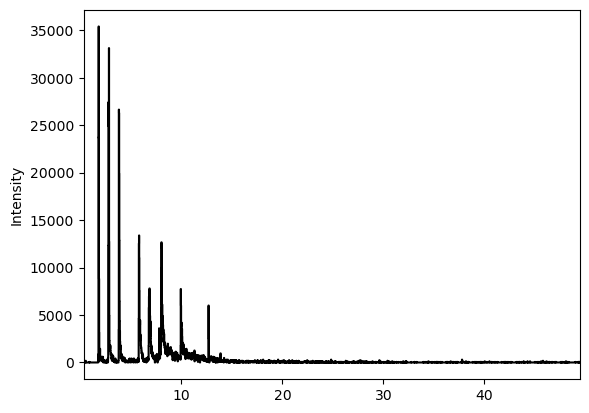

In [12]:
plot_intensity(seq,dt=1/60)

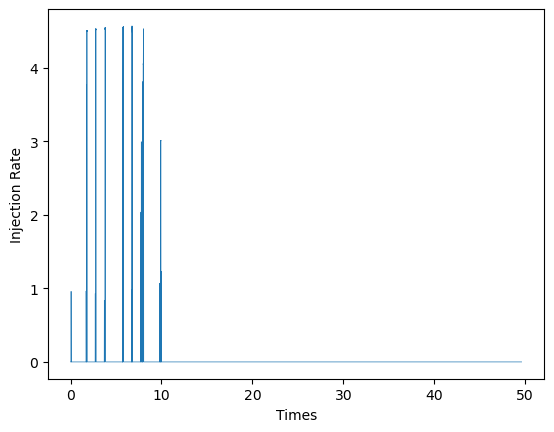

In [13]:
plt.xlabel('Times')
plt.ylabel('Injection Rate')
plt.plot(ts_time, ts,linewidth=0.5,color='tab:blue')

In [14]:
t_arr = seq.arrival_times.cpu().numpy()
T0 =0 
T = float(seq.arrival_times.max())
dt =1/60
edges = np.arange(T0, T + dt, dt)

counts, _ = np.histogram(t_arr, bins=edges)
lam = counts / dt

In [15]:
lam.max()

37560.0

In [16]:
indices = np.nonzero(lam > 500)[0]
indices/60

array([ 1.75      ,  1.76666667,  1.78333333,  1.8       ,  1.81666667,
        1.83333333,  1.85      ,  1.88333333,  1.9       ,  1.91666667,
        1.93333333,  1.95      ,  1.96666667,  2.01666667,  2.03333333,
        2.13333333,  2.21666667,  2.73333333,  2.75      ,  2.76666667,
        2.78333333,  2.8       ,  2.81666667,  2.83333333,  2.85      ,
        2.86666667,  2.88333333,  2.9       ,  2.91666667,  2.93333333,
        2.95      ,  2.96666667,  2.98333333,  3.        ,  3.01666667,
        3.03333333,  3.13333333,  3.16666667,  3.18333333,  3.21666667,
        3.23333333,  3.78333333,  3.8       ,  3.81666667,  3.83333333,
        3.85      ,  3.86666667,  3.88333333,  3.9       ,  3.91666667,
        3.93333333,  3.95      ,  3.96666667,  3.98333333,  4.01666667,
        4.03333333,  4.05      ,  4.06666667,  4.08333333,  4.1       ,
        4.11666667,  4.16666667,  4.38333333,  5.76666667,  5.78333333,
        5.8       ,  5.81666667,  5.83333333,  5.85      ,  5.86

In [17]:
ts_count, edges = np.histogram(t_arr, bins=ts_time)
ts_ = (ts[1:]+ts[:-1])/2
ts_time_ = (ts_time[1:] + ts_time[:-1]) / 2
ts_ = ts_.numpy()
ts_time_ = ts_time_.numpy() 

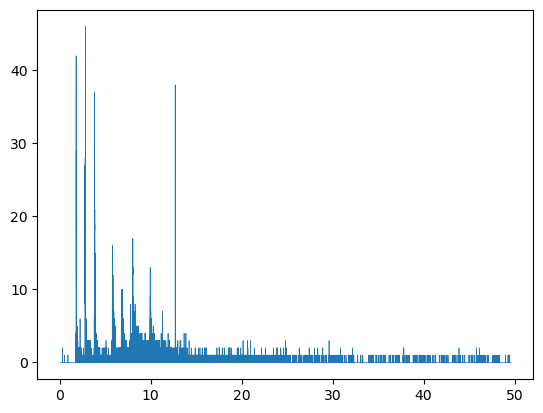

In [18]:
plt.plot(ts_time_, ts_count,linewidth=0.5,color='tab:blue')
# plt.plot(ts_time, ts)

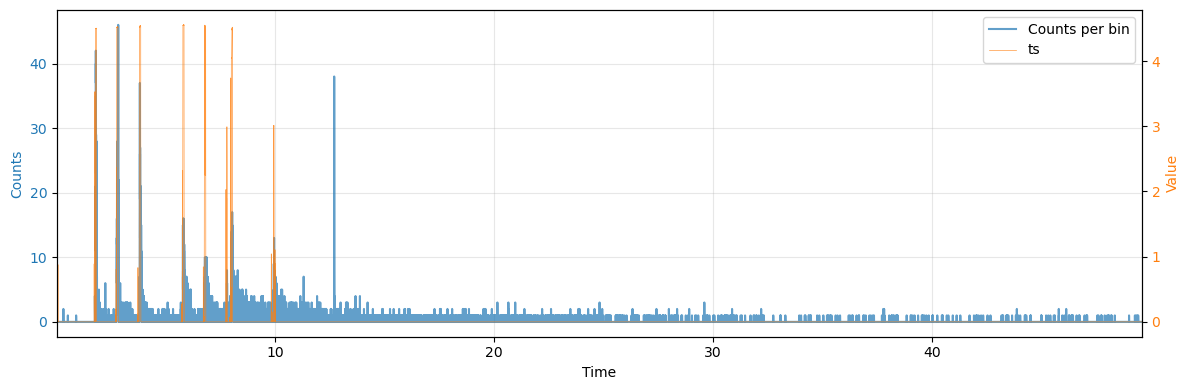

In [19]:
fig, ax1 = plt.subplots(figsize=(12, 4))
l1 = ax1.plot(ts_time[1:].numpy(), ts_count, label="Counts per bin", color="C0", alpha=0.7)
ax1.set_xlabel("Time")
ax1.set_ylabel("Counts", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")
ax1.set_xlim(ts_time.min().item(), ts_time.max().item())
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
l2 = ax2.plot(ts_time_, ts_, label="ts", color="C1", alpha=0.8,linewidth=0.5)
ax2.set_ylabel("Value", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")

lines = l1 + l2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper right")
fig.tight_layout()

In [23]:
start = pd.to_datetime(catalog_ds.metadata['start_ts'])
end1 = pd.to_datetime("2018-10-25 13:28:00")
end2 = pd.to_datetime("2018-10-25 13:55:00")
end3 = pd.to_datetime("2018-10-17 14:00:00")
end4 = pd.to_datetime("2018-12-14 15:00:00")
diff_time1 = (end1 - start) / freq
diff_time2 = (end2 - start) / freq
diff_time3 = (end3 - start) / freq
diff_time4 = (end4 - start) / freq
print(diff_time1)
print(diff_time2)
print(diff_time3)
print(diff_time4)


10.227777777777778
10.246527777777779
2.25
60.291666666666664


injection sum: 388.2665710449219, count sum: 1426.0, ratio: 3.6727344209991593


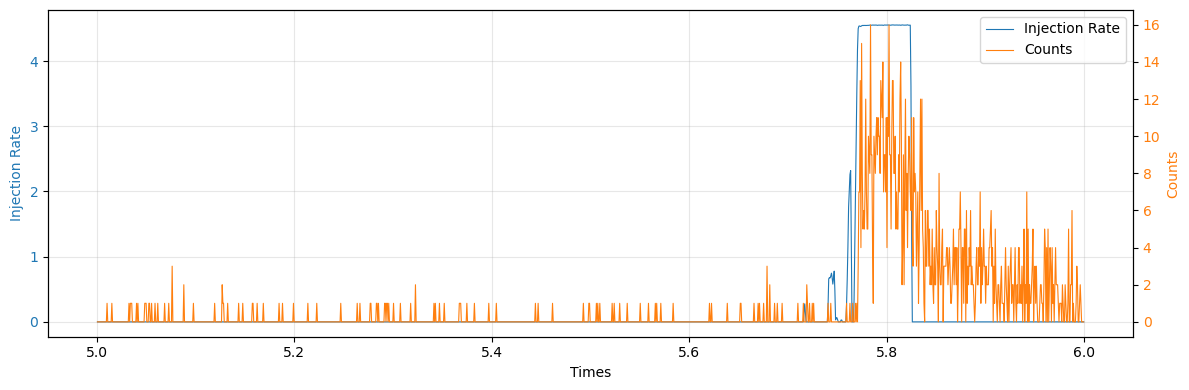

In [27]:
def plot_window(window_start=260, window_len=30, ts_time_=ts_time_, ts_=ts_, ts_count=ts_count, figsize=(12,4), ax=None):
    # convert tensors to numpy once for speed
    t = ts_time_
    inj = ts_
    counts = ts_count  # already numpy

    window_end = window_start + window_len
    mask = (t >= window_start) & (t <= window_end)
    # mask_ = np.roll(mask, -60)

    if ax is None:
        fig, ax1 = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure
        ax1 = ax

    l1 = ax1.plot(t[mask], inj[mask], label="Injection Rate", color="C0", linewidth=0.8)
    ax1.set_xlabel("Times")
    ax1.set_ylabel("Injection Rate", color="C0")
    ax1.tick_params(axis="y", labelcolor="C0")
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    l2 = ax2.plot(t[mask], counts[mask], label="Counts", color="C1", linewidth=0.8) 
    ax2.set_ylabel("Counts", color="C1")
    ax2.tick_params(axis="y", labelcolor="C1")

    lines = l1 + l2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="upper right")
    fig.tight_layout()

    inj_sum = float(inj[mask].sum())
    count_sum = float(counts[mask].sum())
    ratio = count_sum / inj_sum if inj_sum != 0 else float("inf")

    return {"fig": fig, "ax1": ax1, "ax2": ax2, "inj_sum": inj_sum, "count_sum": count_sum, "ratio": ratio}


res = plot_window(window_start=5, window_len=1)
print(f"injection sum: {res['inj_sum']}, count sum: {res['count_sum']}, ratio: {res['ratio']}")

## Find the base points of the peaks

In [28]:
ts_.shape ,ts_time_.shape, ts_count.shape

((71397,), (71397,), (71397,))

找到 20 个符合条件的局部极大值。
索引: [   62  2490  2580  3889  3968  5325  5438  5502  8287  8352  9627  9706
  9776 11117 11180 11432 11531 14102 14266 14344]
数值: [0.8771502  3.530138   4.5052133  0.8086462  4.524561   0.83243406
 4.5363374  4.540781   4.547991   4.555612   0.84413075 4.5507145
 4.4987316  2.02958    2.9918933  3.7414098  4.519515   1.0429393
 3.0094323  1.1062787 ]
------------------------------
--- 基座 (Bases) 结果 ---
左基座 (left_bases) 浮点索引: [   58.          2485.          2528.          3884.
  3912.          5321.          5418.9168178   5406.
  8285.93106693  8273.          9625.          9685.
  9774.         11112.         11169.         11419.
 11457.         14089.         14232.         14336.        ]
右基座 (right_bases) 浮点索引: [   64.          2494.          2601.          3893.
  4015.          5328.          5443.          5510.
  8288.          8359.          9632.          9785.
  9777.27069882 11120.         11190.         11435.
 11544.         14113.         14285.    

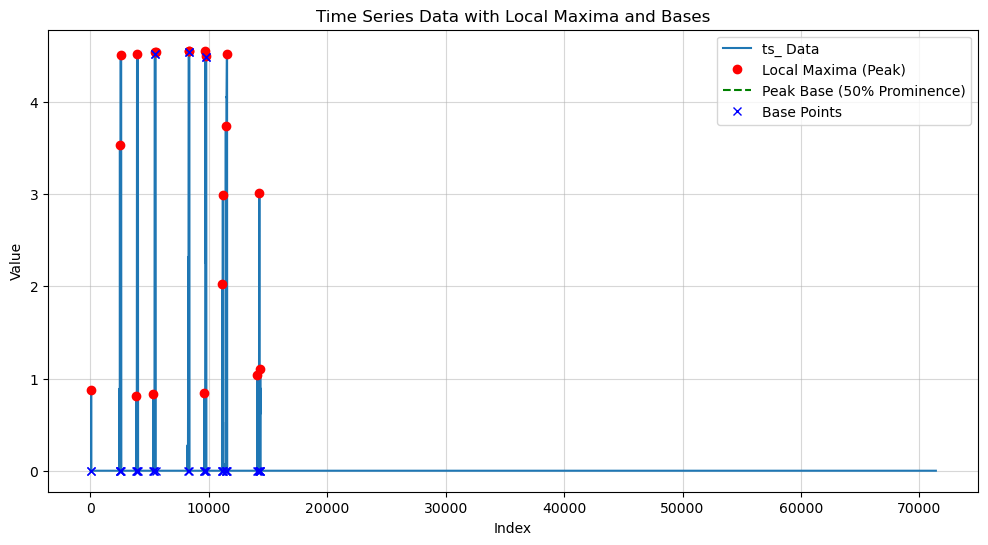

In [29]:
import numpy as np
from scipy.signal import find_peaks, peak_widths
import matplotlib.pyplot as plt

# # --- 1. 模拟数据 (替换为您的 ts_ 实际数据) ---
# # 形状 (92375,) 是一个很长的序列，这里我们用一个较短的序列来模拟
# # 模拟一个包含几个清晰峰值和噪声的时间序列
# np.random.seed(42)  # 设置随机种子以保证结果可重复
# N = 1000 # 模拟数据点数
# # 创建基线数据
# ts_base = 5 + np.sin(np.linspace(0, 10 * np.pi, N))
# # 添加几个主要的峰值
# ts_peaks = np.zeros(N)
# ts_peaks[100:200] = np.hanning(100) * 15 # 第一个峰
# ts_peaks[350:450] = np.hanning(100) * 8  # 第二个峰 (较低)
# ts_peaks[600:700] = np.hanning(100) * 20 # 第三个峰 (最高)
# # 添加少量噪声
# ts_noise = np.random.normal(0, 0.5, N)

# # 最终的模拟 ts_ 数据
# ts_ = ts_base + ts_peaks + ts_noise
# # 确保 ts_ 是一个 NumPy 数组
# ts_ = np.array(ts_) 


peaks_indices, properties = find_peaks(
    ts_, 
    height=0.5, 
    distance=60,
)

local_maxima_values = ts_[peaks_indices]
print(f"找到 {len(peaks_indices)} 个符合条件的局部极大值。")
print(f"索引: {peaks_indices}")
print(f"数值: {local_maxima_values}")
print("-" * 30)


# --- 3. 获取 Left Bases 和 Right Bases ---
# 使用 peak_widths 函数，传入数据和峰值索引
# 参数说明:
#   rel_height=0.5: 在峰高 (峰值到相邻谷底的高度差) 的 50% 处计算宽度和基座
widths_results = peak_widths(
    x=ts_, 
    peaks=peaks_indices, 
    rel_height=1
)

# widths_results 包含四个元素:
# (widths, width_heights, left_ips, right_ips)

widths, width_heights, left_bases_float, right_bases_float = widths_results

left_bases = np.round(left_bases_float).astype(int)
right_bases = np.round(right_bases_float).astype(int)

print(f"--- 基座 (Bases) 结果 ---")
print(f"左基座 (left_bases) 浮点索引: {left_bases_float}")
print(f"右基座 (right_bases) 浮点索引: {right_bases_float}")
print(f"左基座 (left_bases) 整数索引: {left_bases}")
print(f"右基座 (right_bases) 整数索引: {right_bases}")
print("-" * 30)


# --- 4. 绘图展示 (可视化结果) ---
# 可视化是验证峰值查找结果的最佳方式
plt.figure(figsize=(12, 6))
plt.plot(ts_, label='ts_ Data')

plt.plot(peaks_indices, local_maxima_values, "o", color='red', label='Local Maxima (Peak)')

for i in range(len(peaks_indices)):
    plt.hlines(
        y=width_heights[i], 
        xmin=left_bases_float[i], 
        xmax=right_bases_float[i], 
        color='green', 
        linestyle='--', 
        label='Peak Base (50% Prominence)' if i == 0 else "" 
    )

    plt.plot(left_bases_float[i], width_heights[i], "x", color='blue')
    plt.plot(right_bases_float[i], width_heights[i], "x", color='blue', label='Base Points' if i == 0 else "")


plt.title('Time Series Data with Local Maxima and Bases')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

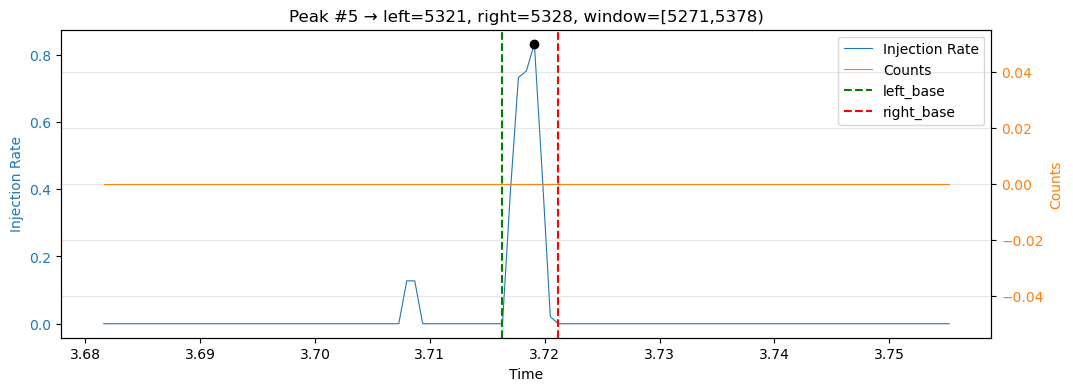

In [30]:
index = 5
offset = 50

# validate index
if index < 0 or index >= len(left_bases):
    raise IndexError(f"index {index} out of range (0..{len(left_bases)-1})")

lb = int(left_bases[index])
rb = int(right_bases[index])
start = max(0, lb - offset)
end = min(len(ts_), rb + offset)

x = ts_time_[start:end]

fig, ax1 = plt.subplots(figsize=(12,4))
ln1 = ax1.plot(x, ts_[start:end], color='tab:blue', label='Injection Rate', linewidth=0.8)
ax1.set_xlabel('Time')
ax1.set_ylabel('Injection Rate', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ln2 = ax2.plot(x, ts_count[start:end], color='tab:orange', label='Counts', linewidth=0.8)
ax2.set_ylabel('Counts', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

ax1.axvline(ts_time_[lb], color='green', linestyle='--', label='left_base')
ax1.axvline(ts_time_[rb], color='red', linestyle='--', label='right_base')

peak_idx = peaks_indices[index]
if start <= peak_idx < end:
    ax1.plot(ts_time_[peak_idx], ts_[peak_idx], 'o', color='black', label='peak')

# combine legends from both axes
lines = ln1 + ln2 + [ax1.lines[-3], ax1.lines[-2]]  # include the vlines and peak if present
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title(f'Peak #{index} → left={lb}, right={rb}, window=[{start},{end})')
plt.grid(alpha=0.3)
plt.show()